training the model

In [1]:
!pip install timm
from fastai.vision.all import *
import timm

In [2]:
path=untar_data(URLs.PETS)/'images'
dls=ImageDataLoaders.from_name_func('.',get_image_files(path),valid_pct=0.2,seed=42,label_func=RegexLabeller(pat=r'^([^/]+)_\d+'),item_tfms=Resize(224))

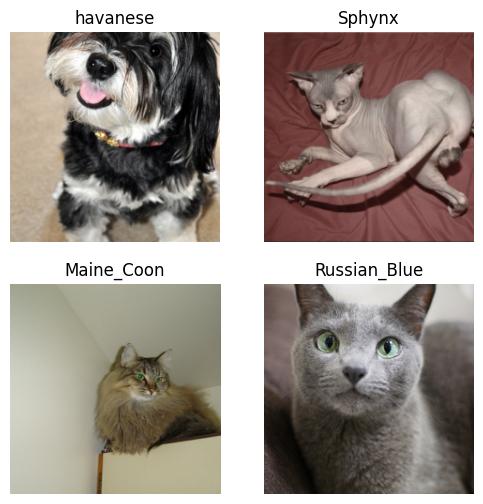

In [3]:
dls.show_batch(max_n=4)

trying different model

In [4]:
timm.list_models('convnext*')

['convnext_atto',
 'convnext_atto_ols',
 'convnext_atto_rms',
 'convnext_base',
 'convnext_femto',
 'convnext_femto_ols',
 'convnext_large',
 'convnext_large_mlp',
 'convnext_nano',
 'convnext_nano_ols',
 'convnext_pico',
 'convnext_pico_ols',
 'convnext_small',
 'convnext_tiny',
 'convnext_tiny_hnf',
 'convnext_xlarge',
 'convnext_xxlarge',
 'convnext_zepto_rms',
 'convnext_zepto_rms_ols',
 'convnextv2_atto',
 'convnextv2_base',
 'convnextv2_femto',
 'convnextv2_huge',
 'convnextv2_large',
 'convnextv2_nano',
 'convnextv2_pico',
 'convnextv2_small',
 'convnextv2_tiny']

In [5]:
learn=vision_learner(dls,'convnext_atto',metrics=error_rate).to_fp16()
learn.fine_tune(3)

/home/a-kuumar/Desktop/Achyut/coding_mat/ml-journey/env/lib/python3.12/site-packages/fastai/callback/fp16.py:47: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  self.autocast,self.learn.scaler,self.scales = autocast('cuda', dtype=dtype),GradScaler('cuda', **self.kwargs),L()
/home/a-kuumar/Desktop/Achyut/coding_mat/ml-journey/env/lib/python3.12/site-packages/fastai/callback/fp16.py:47: UserWarning: torch.cuda.amp.GradScaler is enabled, but CUDA is not available.  Disabling.
  self.autocast,self.learn.scaler,self.scales = autocast('cuda', dtype=dtype),GradScaler('cuda', **self.kwargs),L()


epoch,train_loss,valid_loss,error_rate,time
0,1.333760,0.308743,0.107578,16:05


epoch,train_loss,valid_loss,error_rate,time
0,0.412928,0.247326,0.085250,20:22
1,0.324988,0.191778,0.066982,21:17
2,0.246500,0.197391,0.066982,20:15


In [6]:
learn.export('model.pkl')